# Machine Translation Project: Russian to English (Biomedical Domain)

This Jupyter Notebook serves as an **organized workflow** for training and evaluating a **Neural Machine Translation (NMT) model** using **Sequence-to-Sequence with Attention**.

In [ ]:
# Clone repo from github
#!git clone https://fboglind@github.com/fboglind/lab4_mt_project.git

In [ ]:
# Paperspace Gradient specific code
import os

# Set base directory
base_dir = "/notebooks/lab4_mt_project"
os.chdir(base_dir)

# Verify that the directory change was successful
print("Current working directory:", os.getcwd())

In [ ]:
# Install dependencies (if not installed)
%pip install torch pandas matplotlib seaborn sentencepiece sacrebleu

## **1. Create parallel corpus and test set**
- Reads files containing abstracts
- Creates a parallel corpus
- Creates a test set

The data for this project consists of parallel abstracts which can be retrieved from Medline using a script: wmtbio22_train_data.py.
Biopython and a valid email is needed to access the data in Medline.
https://github.com/biomedical-translation-corpora/corpora/blob/master/wmtbio22_train_data.py

In [31]:
# Assuming that the Medline data has been downloaded and extracted to a directory called abstracts/ we create parallel corpus and test set
%mkdir -p data
!python3 scripts/preprocess_wmt22.py

Preprocessing complete. Saved 11152 sentence pairs to data/parallel_corpus.tsv
Raw test Russian abstracts saved to data/test_raw_ru.txt
Parallel test data saved to data/test_parallel.tsv


## **2. Load & Explore Data**


- Load the parallel corpus
- Analyze text length distributions
- Check for alignment issues
- Clean the data

                                                  Russian  \
count                                               11152   
unique                                              11150   
top     Проанализировано качество оказания помощи паци...   
freq                                                    2   

                                                  English  
count                                               11152  
unique                                              11144  
top     The aim of the study was to elaborate lingual ...  
freq                                                    2  
                                             Russian  \
0  Резюме Цель: Определить, в какой степени грипп...   
1  Резюме Цель: Провести экспертную процедуру опр...   
2  Резюме Цель: Определить влияние еженедельной н...   
3  Резюме Цель: Определить, явилась ли политика б...   
4  Резюме Цель: Оценить проблему туберкулеза со м...   

                                             English  
0 

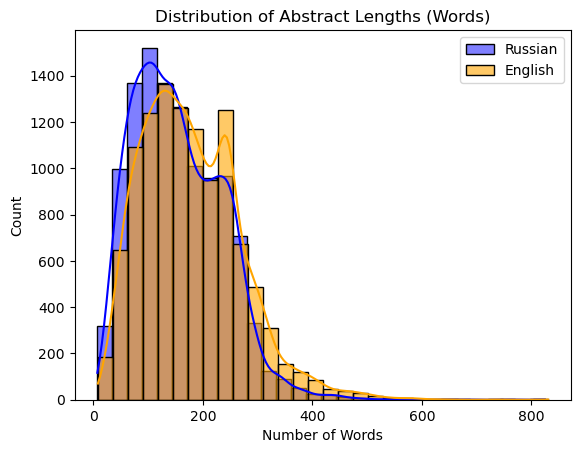

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("data/parallel_corpus.tsv", sep="\t", encoding="utf-8")

# Basic statistics
print(df.describe())
print(df.head())

# Plot text length distributions
df["Russian_Length"] = df["Russian"].apply(lambda x: len(x.split()))
df["English_Length"] = df["English"].apply(lambda x: len(x.split()))

sns.histplot(df["Russian_Length"], bins=30, kde=True, label="Russian", color="blue")
sns.histplot(df["English_Length"], bins=30, kde=True, label="English", color="orange", alpha=0.6)
plt.legend()
plt.title("Distribution of Abstract Lengths (Words)")
plt.xlabel("Number of Words")
plt.ylabel("Count")
plt.show()

Let's remove some of the 'misaligned' abstracts, while also perform some basic cleaning

In [33]:
!python3 scripts/clean_parallel_corpus.py --input data/parallel_corpus.tsv --output data/cleaned_parallel_corpus_initial.tsv

Cleaned parallel corpus saved to data/cleaned_parallel_corpus_initial.tsv


In [34]:
# Check the cleaned data
df = pd.read_csv("data/cleaned_parallel_corpus_initial.tsv", sep="\t", encoding="utf-8")
# Display one column per row for the first lines of the dataframe
for index, row in df.head(10).iterrows():
    print(f"Row {index}:")
    print(f"Russian: {row['Russian']}")
    print(f"English: {row['English']}")
    print(f"Russian_Length: {row['Russian_Length']}")
    print(f"English_Length: {row['English_Length']}")
    print("-" * 50)

Row 0:
Russian: Резюме Цель: Определить, в какой степени грипп способствует заражению лиц всех возрастов в Бангладеш тяжелой острой респираторной инфекцией (ТОРИ), которая является основной причиной детской смертности. Методы: Врачами были взяты мазки из носа и зева для анализа на вирус гриппа у пациентов, которые были госпитализированы в течение семи дней от начала заболевания тяжелой острой респираторной инфекцией (ТОРИ) или консультировались у врача в амбулаторном режиме по поводу гриппоподобной болезни (ГПБ). Было проведено исследование пользования медико-санитарной помощью на уровне общин для определения доли жителей участка, обслуживаемого больницей, которые обращались за помощью в обследуемые медицинские учреждения, и расчета заболеваемости гриппом с использованием указанного показателя в качестве знаменателя. Результаты: Оценочные показатели заболеваемости ТОРИ, коррелируемой с гриппом, у детей в возрасте до 5 лет, составили 6,7 (95% доверительный интервал, ДИ: 0-18,3); 4,4 (95

By looking at the first lines we can see that the Russian text contain some reocurring opening phrases that have no counterpart in the English text. 

We scan the text for such common opening phrases while also checking if they have any corresponding English phrases:

In [35]:
!python3 scripts/extract_openers_from_english.py


🔹 Russian Opener: ^Цель исследования  (Count: 2402)
   to study the                             264
   the objective of                         200
   to evaluate the                          161
   the aim of                               133
   to assess the                            91
   to investigate the                       85
   to analyze the                           68
   to determine the                         66
   the purpose of                           58
   to estimate the                          43

🔹 Russian Opener: ^Цель работы  (Count: 268)
   the objective of                         133
   the purpose of                           30
   the aim of                               24
   to study the                             5
   the study was                            4
   to evaluate the                          4
   to improve the                           3
   to analyze the                           3
   to assess the                            3
   aim of

We remove these opening phrases from the Russian texts together with common headers (ex. "Результаты и обсуждение" - "Results and discussion" etc.) as these are not present in the English text either.

In [36]:
!python3 scripts/clean_russian_openers.py
!head data/cleaned_parallel_corpus.tsv

Cleaned file saved to: data/cleaned_parallel_corpus.tsv
Russian	English	Russian_Length	English_Length	Length_Ratio
Определить, в какой степени грипп способствует заражению лиц всех возрастов в Бангладеш тяжелой острой респираторной инфекцией (ТОРИ), которая является основной причиной детской смертности. Методы: Врачами были взяты мазки из носа и зева для анализа на вирус гриппа у пациентов, которые были госпитализированы в течение семи дней от начала заболевания тяжелой острой респираторной инфекцией (ТОРИ) или консультировались у врача в амбулаторном режиме по поводу гриппоподобной болезни (ГПБ). Было проведено исследование пользования медико-санитарной помощью на уровне общин для определения доли жителей участка, обслуживаемого больницей, которые обращались за помощью в обследуемые медицинские учреждения, и расчета заболеваемости гриппом с использованием указанного показателя в качестве знаменателя.  Оценочные показатели заболеваемости ТОРИ, коррелируемой с гриппом, у детей в возраст

The abstracts are quite long, we therefore split them into sentences before further tokenization.

In [37]:
!python3 scripts/split_abstracts.py --input data/cleaned_parallel_corpus.tsv --output data/sentence_aligned_corpus.tsv

Sentence-aligned corpus saved to data/sentence_aligned_corpus.tsv


In [ ]:
# We also split the test set
!python3 scripts/split_abstracts.py \
  --input data/test_parallel.tsv \
  --output data/test_parallel_sentences.tsv

# Extract the raw Russian sentences to create a proper test set
!cut -f1 data/test_parallel_sentences.tsv > data/test_raw_ru_sentences.txt
print(f"Monolingual test set saved to data/test_raw_ru_sentences.txt")

[DEBUG] Abstract 0: 8 Russian / 8 English sentences
[DEBUG] Abstract 1: 8 Russian / 11 English sentences
[WARNING] Abstract 1 has significant sentence count mismatch: 8 vs 11
[DEBUG] Abstract 2: 10 Russian / 11 English sentences
[DEBUG] Abstract 3: 6 Russian / 6 English sentences
[DEBUG] Abstract 4: 3 Russian / 3 English sentences
[DEBUG] Abstract 5: 6 Russian / 8 English sentences
[DEBUG] Abstract 6: 7 Russian / 7 English sentences
[DEBUG] Abstract 7: 7 Russian / 8 English sentences
[DEBUG] Abstract 8: 4 Russian / 4 English sentences
[DEBUG] Abstract 9: 6 Russian / 6 English sentences
[DEBUG] Abstract 10: 10 Russian / 9 English sentences
[DEBUG] Abstract 11: 4 Russian / 7 English sentences
[WARNING] Abstract 11 has significant sentence count mismatch: 4 vs 7
[DEBUG] Abstract 12: 9 Russian / 9 English sentences
[DEBUG] Abstract 13: 6 Russian / 6 English sentences
[DEBUG] Abstract 14: 4 Russian / 4 English sentences
[DEBUG] Abstract 15: 5 Russian / 5 English sentences
[DEBUG] Abstract 1

In [ ]:
# Check if any misaligned sentences remain
import pandas as pd
df = pd.read_csv("data/sentence_aligned_corpus.tsv", sep="\t", encoding="utf-8")

# Check for misaligned rows
misaligned = df[(df["Russian"].str.len() < 10) | (df["English"].str.len() < 10)]
print(f"⚠️ Found {len(misaligned)} potentially broken rows.")

# Check for newline artifacts
newline_issues = df[df["Russian"].str.contains("\n") | df["English"].str.contains("\n")]
print(f" Found {len(newline_issues)} rows with embedded newlines.")


⚠️ Found 0 potentially broken rows.
 Found 0 rows with embedded newlines.


Moving on, we scan the Russian text for Latin terms

In [ ]:
import re

def contains_latin(text):
    return bool(re.search(r"[A-Za-z]{2,}", text))

def highlight_latin(text):
    # Highlight words with Latin chars in red
    return re.sub(r"([A-Za-z]{2,})", r"\033[91m\1\033[0m", text)

# Filter or flag those rows
df_with_latin = df[df["Russian"].apply(contains_latin)]
print(f"Found {len(df_with_latin)} rows with Latin characters in Russian.")

for i, row in df.iterrows():
    if contains_latin(row["Russian"]):
        highlighted_text = highlight_latin(row["Russian"])
        print(f"[{i}] {highlighted_text}")


Found 4624 rows with Latin characters in Russian.
[1] Провести экспертную процедуру определения научно-исследовательских приоритетов в области сексуального и репродуктивного здоровья подростков в странах с низким и средним уровнем доходов. Методы: Авторы изменили метод определения приоритетов Инициативы по исследованиям детского здоровья и питания (CHNRI) для получения информации приблизительно от 300 исследователей, доноров и руководителей программ здравоохранения, обладающих обширными знаниями и опытом, со всех географических регионов мира. В ходе трехступенчатой процедуры экспертов просили: (i) оценить целевые области по степени важности; (ii) сформулировать исследовательские вопросы по каждой области и (iii) расставить сформулированные вопросы в порядке приоритетности.  Семь важных областей сексуального и репродуктивного здоровья подростков были определены как важные: (i) материнское здоровье; (ii) контрацепция; (iii) гендерное насилие; (iv) лечение и уход за пациентами с вирусом и

We also want to find numeral characters, as these are likely the same in both texts. We then save both the Latin terms and the numerals to a file

In [42]:
# Extract numbers and Latin characters and save them to a file
!python3 scripts/extract_numbers_and_latin.py

Top Latin-script terms:
sub                  1038
sup                  758
II                   460
III                  362
COVID-19             320
in                   198
IV                   192
D-                   133
CD4                  102
MMSE                 100
of                   99
Ki-67                99
vitro                94
PubMed               91
NIHSS                91
VEGF                 91
PANSS                89
I-II                 82
pylori               81
SF-36                76
BDNF                 75
TNF-                 71
VEGF-                71
S100                 66
IL-6                 64
IgG                  64
Grade                63
II-III               62
ROC-                 62
vivo                 60
L-                   60
p0                   59
ii                   56
OR                   54
spp                  53
HER2                 53
SARS-CoV-2           53
Wistar               52
IL-                  51
iii                  50
HbA1 

## **3. Preprocessing: SentencePiece Tokenization**

- Extract source language data
- Train a SentencePiece model
- Tokenize the training and test sets

In [43]:


# Train SentencePiece. Output: spm_ru_en.model, spm_ru_en.vocab
!mkdir -p models
!python3 scripts/sentencepiece_train.py

Loaded 4967 user-defined symbols
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: data/sentence_aligned_corpus.tsv
  input_format: 
  model_prefix: models/spm_ru_en
  model_type: UNIGRAM
  vocab_size: 34967
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  user_defined_symbols: sub
  user_defined_symbols: sup
  user_defined_symbols: II
  user_defined_symbols: III
  user_defined_symbols: COVID-19
  user_defined_symbols: in
  user_defined_symbols: IV
  user_defined_symbols: D-
  user_defined_symbols: CD4
  user_defined_symbols: MMSE
  user_defined

In [ ]:
# Check output - our numerals and Latin chars have 0 probs
!head -n20 models/spm_ru_en.vocab

<unk>	0
<s>	0
</s>	0
sub	0
sup	0
II	0
III	0
COVID-19	0
in	0
IV	0
D-	0
CD4	0
MMSE	0
of	0
Ki-67	0
vitro	0
PubMed	0
NIHSS	0
VEGF	0
PANSS	0


After having trained a Sentencepiece model, we apply the model to the corpus

In [45]:
# Apply SentencePiece Tokenization
!python3 scripts/apply_sentencepiece.py --input data/sentence_aligned_corpus.tsv --output data/spm_parallel_corpus.tsv --model models/spm_ru_en.model --to_parallel

Tokenizing PARALLEL columns...
SentencePiece tokenization complete. Processed 11007              sentences. Saved to data/spm_parallel_corpus.tsv


In [46]:
#Checks output
!head -n 5 data/spm_parallel_corpus.tsv

Russian	English	Russian_Length	English_Length	Length_Ratio
▁Определить , ▁в ▁как ой ▁степени ▁грипп ▁способству ет ▁за р ажен ию ▁лиц ▁всех ▁возрастов ▁в ▁Б англ а де ш ▁тяжелой ▁острой ▁респираторн ой ▁ инфекцией ▁( Т ОРИ ), ▁которая ▁является ▁основной ▁причиной ▁детск ой ▁смертности . ▁Методы : ▁ Врач ами ▁были ▁взяты ▁ ма з ки ▁из ▁носа ▁и ▁ з ева ▁для ▁анализа ▁на ▁ вирус ▁гриппа ▁у ▁пациентов , ▁которые ▁были ▁ госпитализирован ы ▁в ▁течение ▁семи ▁дней ▁от ▁начала ▁заболевания ▁тяжелой ▁острой ▁респираторн ой ▁ инфекцией ▁( Т ОРИ ) ▁или ▁ ко нсульт ировали сь ▁у ▁врача ▁в ▁амбулаторн ом ▁режиме ▁по ▁по воду ▁грипп оподобн ой ▁болезни ▁( ГП Б ). ▁Был о ▁проведен о ▁исследование ▁ поль з ования ▁медико - санитарн ой ▁помощью ▁на ▁уровне ▁общ ин ▁для ▁определения ▁доли ▁жителей ▁участка , ▁об с луж ива емого ▁больнице й , ▁которые ▁обращались ▁за ▁помощью ▁в ▁обследуем ые ▁ медицинские ▁учреждения , ▁и ▁расчета ▁заболеваемости ▁грипп ом ▁с ▁использованием ▁указанн ого ▁показателя ▁

We should also tokenize the test set

In [13]:
# Apply sentencepiece to the test set
!python3 scripts/apply_sentencepiece.py \
  --input data/test_raw_ru_sentences.txt \
  --output data/preprocessed_test_set.tsv\
  --is_test_set

SentencePiece tokenization complete. Processed 51              TEST sentences. Saved to data/preprocessed_test_set.tsv


In [48]:
# Check
!head -n 5 data/preprocessed_test_set.tsv

▁Russian
▁Реализаци я ▁эффективной ▁меж с ек тор альной ▁политики ▁в ▁области ▁питания ▁оста ется ▁сложной ▁задачей , ▁актуальной ▁во ▁всем ▁мире . ▁Из уч ая ▁отчеты ▁с ов е щ а ний ▁и ▁консультаци й ▁Всемирн ой ▁организации ▁здравоохранения ▁( ВОЗ ), ▁с оз ы ваемых ▁для ▁политическ ого ▁руководства ▁ го с удар ст в - ч лен ов ▁региона ▁западн ой ▁части ▁Т их ого ▁ ок е ана , ▁авторы ▁со об щ или ▁ о ▁том , ▁как ▁лица , ▁определяющи е ▁национальн ую ▁политику , ▁ а ▁также ▁внешни е ▁субъект ы ▁могут ▁поддержива ть ▁различны е ▁уровн и ▁реализации ▁политики ▁в ▁области ▁питания . ▁Ключев ые ▁в ы вод ы ▁политическ ого ▁руководства , ▁участвующе го ▁в ▁с ов е щ а ния х ▁по ▁вопросам ▁про дов оль ст ви я ▁и ▁питания , ▁включают ▁в ▁себя ▁то , ▁что ▁реализаци я ▁политики ▁в ▁области ▁питания ▁на ▁уровне ▁стран ▁опира ется ▁на ▁четк ую ▁разработк у ▁политики , ▁ организационно е ▁планировани е ▁и ▁механизмы ▁управления , ▁которые ▁способствую т ▁коллективн ой ▁ответственности ▁во ▁многи х ▁с

## **4. Model Training**

- Train the sequence-to-sequence model
- Use label smoothing to improve training stability
- Save the trained model

In [ ]:
# Train the model with accumulated gradients (batch size 8, gradient accumulation steps 4)
# !python3 scripts/seq2seq_train.py \ 
#   --batch-size 8 \
#   --accum-steps 4

# Or to run in background use:
# ./run_training.sh

IndentationError: unexpected indent (764372082.py, line 3)

## **5. Translation & Evaluation**

- Extract reference translations
- Translate test data
- Evaluate performance using BLEU and chrF

In [14]:
# !python3 scripts/extract_references.py \
#   --parallel data/sentence_aligned_corpus.tsv \
#   --test data/test_raw_ru_sentences.txt \
#   --output data/test_reference_en.txt \
#   --src-col Russian \
#   --tgt-col English

!python3 scripts/extract_references.py \
  --parallel data/test_parallel_sentences.tsv \
  --test data/test_raw_ru_sentences.txt \
  --output data/test_reference_en.txt \
  --src-col Russian \
  --tgt-col English


2025-03-27 21:39:50 - INFO - Loading parallel corpus from data/test_parallel_sentences.tsv
2025-03-27 21:39:50 - INFO - Reading test sentences from data/test_raw_ru_sentences.txt
2025-03-27 21:39:50 - INFO - Found 51 test sentences
2025-03-27 21:39:50 - WARNING - No match found for test sentence: Russian...
2025-03-27 21:39:50 - INFO - Found references for 50 out of 51 test sentences
2025-03-27 21:39:50 - INFO - Reference translations saved to data/test_reference_en.txt
2025-03-27 21:39:50 - INFO - Reference extraction completed successfully


In [ ]:
# Translate test set
!python3 scripts/translate_wmt_test.py

In [ ]:
# Evaluate translations
!python3 scripts/evaluate_translations.py \
  --hyp data/test_hypothesis_en.txt \
  --ref data/test_reference_en.txt \


## Final Evaluation Summary

| Metric  | Score     |
|---------|-----------|
| BLEU    | --.--     |
| chrF    | --.--     |


Evaluation performed on sentence-level translations using sacreBLEU.


## **6. Next Steps & Improvements**

- Compare GRU vs. LSTM architectures
- Fine-tune hyperparameters for better results